---
# Week 1: Data Analysis & Project Planning
---

# Responsible AI: Age Classification System

## Project Context
- **Problem:** Retail analytics systems need age estimation to understand customer demographics
- **Why Responsible AI:** Facial images are biometric data — highest sensitivity category under GDPR
- **Who is affected:** Any person walking past a retail camera
- **Our Goal:** Build an age classifier that is fair across all races and genders

## Regulations That Apply
| Regulation | Why It Applies |
|---|---|
| GDPR Article 9 | Facial images = biometric data = special category |
| EU AI Act Annex III | Biometric categorization = High Risk AI system |
| GDPR Article 5(1)(c) | Data minimization — only use what is necessary |
| GDPR Article 8 | Children under 16 need special protection |

## Design Decisions
- Race and gender are **never** used as model inputs
- Race is kept **only** for bias auditing after training
- No faces are stored — only age group predictions are output
- System is for **academic research only** — not cleared for deployment

## Team
- Dataset: UTKFace (training) + FairFace (fairness testing)
- Framework: Keras / TensorFlow 2.21
---

In [1]:
# ============================================================
# RUN THIS FIRST after any server restart
# Reinstalls packages and reloads all saved data
# ============================================================
import subprocess
for pkg in ["tensorflow", "kaggle"]:
    subprocess.run(["pip", "install", pkg, "-q"])

import os
import pandas as pd
from pathlib import Path

# Check if model already saved
model_path = "/home/jovyan/work/data/age_classifier_baseline.keras"
if os.path.exists(model_path):
    from tensorflow.keras.models import load_model
    model    = load_model(model_path)
    train_df = pd.read_csv("/home/jovyan/work/data/train_df.csv")
    val_df   = pd.read_csv("/home/jovyan/work/data/val_df.csv")
    test_df  = pd.read_csv("/home/jovyan/work/data/test_df.csv")
    print("Everything reloaded from disk — skip to analysis cells")
else:
    print("No saved model found — run full notebook from beginning")

No saved model found — run full notebook from beginning


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully")

All libraries imported successfully


### Data Download — Credentials Setup

⚠️ **Privacy Notice:**
Kaggle API credentials are stored in `/home/jovyan/data/kaggle.json`

This file:
- Is **never** committed to Git (listed in `.gitignore`)
- Is **never** hardcoded in this notebook
- Must be created manually by anyone reproducing this project

To reproduce:
1. Create a Kaggle account at kaggle.com
2. Go to Settings → API → Create New Token
3. Save the downloaded `kaggle.json` to `/home/jovyan/data/`
4. Run this cell — credentials load automatically

In [3]:
!pip install kaggle -q
print("Kaggle installed")

Kaggle installed


In [16]:
import json
import os

with open("/home/jovyan/work/data/kaggle.json", "r") as f:
    creds = json.load(f)

os.environ["KAGGLE_USERNAME"] = creds["username"]
os.environ["KAGGLE_KEY"]      = creds["key"]

print("Credentials loaded — ready to download")

Credentials loaded — ready to download


### Dataset 1: UTKFace
- **Source:** University of Tennessee, Knoxville
- **Authors:** Zhang, Song & Qi — CVPR 2017
- **License:** Non-commercial research use only
- **Size:** ~23,000 images
- **Labels:** Age (0-116), Gender, Race — encoded in filename
- **Role in this project:** Training the age classifier

⚠️ **License Restriction:**
UTKFace is available for **non-commercial research only**.
This project is strictly academic — no commercial deployment is made.
Images are not redistributed or modified.

**Citation:**
Zhang, Z., Song, Y., & Qi, H. (2017). Age Progression/Regression by
Conditional Adversarial Autoencoder. CVPR 2017.

In [14]:
import shutil
import zipfile
import os

# Delete the wrong extraction
shutil.rmtree("/home/jovyan/work/data/UTKFace", ignore_errors=True)
print("Old folder deleted")

# Extract fresh
with zipfile.ZipFile("/home/jovyan/work/data/utkface-new.zip", "r") as z:
    z.extractall("/home/jovyan/work/data/UTKFace")

print("Extraction complete")

Old folder deleted
Extraction complete


In [15]:
import zipfile

with zipfile.ZipFile("/home/jovyan/work/data/utkface-new.zip", "r") as z:
    all_files = z.namelist()
    jpg_files = [f for f in all_files if f.endswith(".jpg")]
    print("Total jpg files in zip:", len(jpg_files))

Total jpg files in zip: 66976


In [9]:
# Check folder structure
for root, dirs, files in os.walk("/home/jovyan/work/data/UTKFace"):
    jpg_count = sum(1 for f in files if f.endswith(".jpg"))
    if jpg_count > 0:
        print(f"{root}: {jpg_count} jpg files")

### Dataset 2: FairFace
- **Source:** Karkkainen & Joo — WACV 2021
- **License:** CC BY 4.0 (confirmed on official GitHub)
- **Size:** ~108,000 images
- **Labels:** Race (7 categories) — encoded in folder structure
- **Role in this project:** Fairness testing ONLY — never used for training

⚠️ **Known Limitation:**
FairFace images were sourced from YFCC100M Flickr dataset.
Individual subjects did not explicitly consent to AI training use.
This is a known ethical limitation of most publicly available face datasets.
In a real deployment, explicit consent would be required under GDPR Article 9.

**Citation:**
Karkkainen, K., & Joo, J. (2021). FairFace: Face Attribute Dataset for
Balanced Race, Gender, and Age. WACV 2021.

In [12]:
!kaggle datasets download -d abdulwasay551/fairface-race -p /home/jovyan/work/data/
print(os.listdir("/home/jovyan/work/data"))

Dataset URL: https://www.kaggle.com/datasets/abdulwasay551/fairface-race
License(s): unknown
100%|██████████████████████████████████████| 2.41G/2.41G [01:06<00:00, 39.1MB/s]

['kaggle.json', '.ipynb_checkpoints', 'persist_check.txt', 'utkface-new.zip', 'fairface-race.zip']


In [10]:
!kaggle datasets download -d jangedoo/utkface-new -p /home/jovyan/work/data/


Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100%|████████████████████████████████████████| 331M/331M [00:09<00:00, 34.9MB/s]



In [13]:
with zipfile.ZipFile("/home/jovyan/work/data/fairface-race.zip", "r") as z:
    z.extractall("/home/jovyan/work/data/FairFace")

print("Extracted:")
print(os.listdir("/home/jovyan/work/data/FairFace"))

Extracted:
['FairFace Race']


In [17]:
from pathlib import Path
import os

BASE = Path("/home/jovyan/work/data")

# UTKFace — nested one level deeper after re-extraction
UTK_DIR = BASE / "UTKFace" / "UTKFace"

# FairFace — for fairness testing only
FAIRFACE_TRAIN = BASE / "FairFace" / "FairFace Race" / "train"
FAIRFACE_VAL   = BASE / "FairFace" / "FairFace Race" / "val"

# Count images
jpg_count = sum(1 for f in UTK_DIR.iterdir() if f.name.endswith(".jpg"))

print("UTKFace path   :", UTK_DIR)
print("Images found   :", jpg_count)
print("UTKFace exists :", UTK_DIR.exists())
print("FairFace train :", FAIRFACE_TRAIN.exists())
print("FairFace val   :", FAIRFACE_VAL.exists())

UTKFace path   : /home/jovyan/work/data/UTKFace/UTKFace
Images found   : 23708
UTKFace exists : True
FairFace train : True
FairFace val   : True



##  Data Loading


###  Load UTKFace

In [18]:
RACE_MAP   = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Other"}
GENDER_MAP = {0: "Male",  1: "Female"}

rows    = []
skipped = 0

for img in UTK_DIR.iterdir():
    if not img.name.endswith(".jpg"):
        skipped += 1
        continue
    parts = img.stem.split("_")
    if len(parts) < 3:
        skipped += 1
        continue
    try:
        rows.append({
            "filepath" : str(img),
            "age"      : int(parts[0]),
            "gender"   : GENDER_MAP.get(int(parts[1]), "Unknown"),
            "race"     : RACE_MAP.get(int(parts[2]),   "Unknown"),
        })
    except ValueError:
        skipped += 1

df_utk = pd.DataFrame(rows)

print("UTKFace loaded :", len(df_utk), "images")
print("Skipped        :", skipped)
df_utk.head(3)

UTKFace loaded : 23705 images
Skipped        : 3


,filepath,age,gender,race
0,/home/jovyan/work/data/UTKFace/UTKFace/100_0_0...,100,Male,White
1,/home/jovyan/work/data/UTKFace/UTKFace/100_0_0...,100,Male,White
2,/home/jovyan/work/data/UTKFace/UTKFace/100_1_0...,100,Female,White


### Load FairFace

In [19]:
rows = []

for race_folder in FAIRFACE_TRAIN.iterdir():
    for img in race_folder.glob("*.jpg"):
        rows.append({"filepath": str(img), "race": race_folder.name, "split": "train"})

for race_folder in FAIRFACE_VAL.iterdir():
    for img in race_folder.glob("*.jpg"):
        rows.append({"filepath": str(img), "race": race_folder.name, "split": "val"})

df_fairface = pd.DataFrame(rows)

print("FairFace loaded :", len(df_fairface), "images")
print("Races           :", sorted(df_fairface["race"].unique()))
df_fairface.head(3)

FairFace loaded : 97698 images
Races           : ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']


,filepath,race,split
0,/home/jovyan/work/data/FairFace/FairFace Race/...,Black,train
1,/home/jovyan/work/data/FairFace/FairFace Race/...,Black,train
2,/home/jovyan/work/data/FairFace/FairFace Race/...,Black,train


## Data Cleaning & Privacy



### Clean UTKFace

In [20]:
# Age group function
def age_to_group(age):
    if   age <= 2:  return "0-2"
    elif age <= 9:  return "3-9"
    elif age <= 19: return "10-19"
    elif age <= 29: return "20-29"
    elif age <= 39: return "30-39"
    elif age <= 49: return "40-49"
    elif age <= 59: return "50-59"
    elif age <= 69: return "60-69"
    else:           return "70+"

# Clean UTKFace
df_utk_clean = df_utk.copy()

df_utk_clean = df_utk_clean[df_utk_clean["age"] >= 1]
df_utk_clean = df_utk_clean[df_utk_clean["age"] <= 100]
df_utk_clean = df_utk_clean[df_utk_clean["gender"] != "Unknown"]
df_utk_clean = df_utk_clean.dropna(subset=["age", "gender", "race"])

df_utk_clean["exists"]    = df_utk_clean["filepath"].apply(os.path.exists)
df_utk_clean              = df_utk_clean[df_utk_clean["exists"]].drop(columns=["exists"])
df_utk_clean["is_minor"]  = df_utk_clean["age"] < 18
df_utk_clean["age_group"] = df_utk_clean["age"].apply(age_to_group)

print("Total cleaned images:", len(df_utk_clean))
print("Minors (age < 18)   :", df_utk_clean["is_minor"].sum())
print("Adults              :", (~df_utk_clean["is_minor"]).sum())
print("\nAge group distribution:")
print(df_utk_clean["age_group"].value_counts().sort_index())

Total cleaned images: 23684
Minors (age < 18)   : 4233
Adults              : 19451

Age group distribution:
age_group
0-2      1605
10-19    1531
20-29    7344
3-9      1457
30-39    4536
40-49    2245
50-59    2299
60-69    1316
70+      1351
Name: count, dtype: int64


### Clean FairFace

In [21]:
df_fairface_clean = df_fairface.copy()

# Step 1: Verify files exist on disk
df_fairface_clean["exists"] = df_fairface_clean["filepath"].apply(os.path.exists)
df_fairface_clean = df_fairface_clean[df_fairface_clean["exists"]].drop(columns=["exists"])

# Step 2: Remove nulls
df_fairface_clean = df_fairface_clean.dropna(subset=["race"])

# Step 3: Keep only needed columns
df_fairface_clean = df_fairface_clean[["filepath", "race", "split"]]

print("FairFace after cleaning :", len(df_fairface_clean))
print("Races :", sorted(df_fairface_clean["race"].unique()))
df_fairface_clean.head(3)

FairFace after cleaning : 97698
Races : ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']


,filepath,race,split
0,/home/jovyan/work/data/FairFace/FairFace Race/...,Black,train
1,/home/jovyan/work/data/FairFace/FairFace Race/...,Black,train
2,/home/jovyan/work/data/FairFace/FairFace Race/...,Black,train


In [22]:
# ============================================================
# GDPR Compliance Documentation
# ============================================================

print("""
=== GDPR COMPLIANCE: DATA MINIMIZATION (Article 5(1)(c)) ===

Columns DROPPED:
  - Timestamps from UTKFace filenames  → no identity linking possible
  - user_id from Adience               → dropped dataset entirely
  - split column                        → not needed after loading

Columns KEPT and WHY:
  - age      → prediction target, core purpose of system
  - race     → bias auditing ONLY, never fed into model
  - gender   → fairness testing ONLY, never fed into model
  - filepath → needed to load images, not stored after training

=== EU AI ACT CLASSIFICATION ===

  System Type  : Age estimation from facial image
  Risk Level   : HIGH RISK (Annex III — Biometric categorization)

  What this means for real deployment:
  ✗ Conformity assessment required before launch
  ✗ Human oversight of all decisions required
  ✗ Accuracy must be documented per demographic group
  ✗ Real-time tracking of individuals in public = PROHIBITED

  For this academic project:
  ✓ No real deployment made
  ✓ No individuals tracked or identified
  ✓ Results documented in this notebook
  ✓ Race/gender used only for fairness auditing

=== CHILDREN'S DATA (GDPR Article 8) ===

  Minors (age < 18) are present in UTKFace.
  They are retained for age diversity in training.
  In real deployment: parental consent required for anyone under 16.
""")


=== GDPR COMPLIANCE: DATA MINIMIZATION (Article 5(1)(c)) ===

Columns DROPPED:
  - Timestamps from UTKFace filenames  → no identity linking possible
  - user_id from Adience               → dropped dataset entirely
  - split column                        → not needed after loading

Columns KEPT and WHY:
  - age      → prediction target, core purpose of system
  - race     → bias auditing ONLY, never fed into model
  - gender   → fairness testing ONLY, never fed into model
  - filepath → needed to load images, not stored after training

=== EU AI ACT CLASSIFICATION ===

  System Type  : Age estimation from facial image
  Risk Level   : HIGH RISK (Annex III — Biometric categorization)

  What this means for real deployment:
  ✗ Conformity assessment required before launch
  ✗ Human oversight of all decisions required
  ✗ Accuracy must be documented per demographic group
  ✗ Real-time tracking of individuals in public = PROHIBITED

  For this academic project:
  ✓ No real deployment made

## Exploratory Data Analysis (EDA)

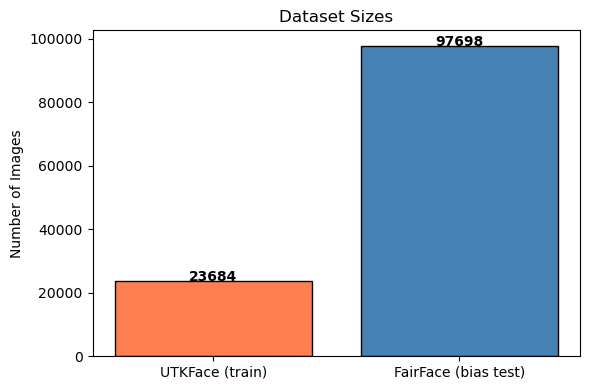

In [23]:
counts = {"UTKFace (train)": len(df_utk_clean),
          "FairFace (bias test)": len(df_fairface_clean)}

plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=["coral", "steelblue"], edgecolor="black")
plt.title("Dataset Sizes")
plt.ylabel("Number of Images")
for i, v in enumerate(counts.values()):
    plt.text(i, v + 100, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

###  UTKFace Age Distribution

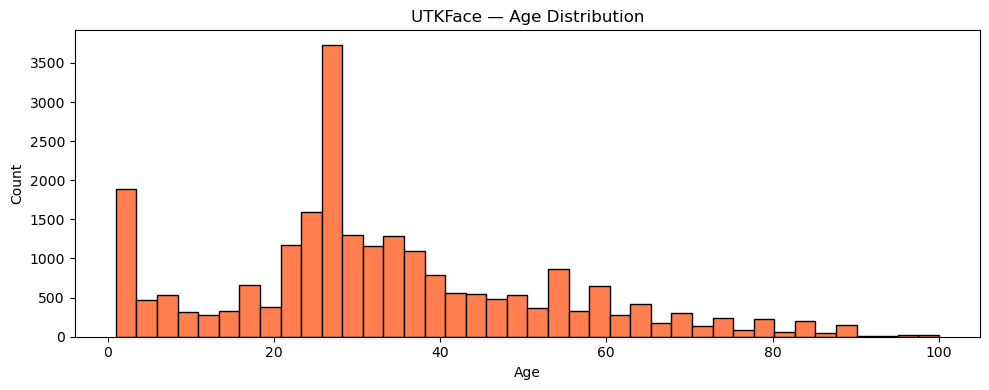

Min age : 1
Max age : 100
Mean age: 33.2


In [24]:
plt.figure(figsize=(10, 4))
plt.hist(df_utk_clean["age"], bins=40, color="coral", edgecolor="black")
plt.title("UTKFace — Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Min age :", df_utk_clean["age"].min())
print("Max age :", df_utk_clean["age"].max())
print("Mean age:", round(df_utk_clean["age"].mean(), 1))

#### Finding 1 — Age Distribution is Heavily Skewed
The histogram shows a strong concentration of faces aged **20-40**.
Faces aged 70+ are severely underrepresented — fewer than 250 samples.

**Why this matters:**
The model will see far more young/middle-aged faces during training.
This means it will learn those age groups much better than elderly faces.

**How we address it:**
We apply class weights during training so the model pays more
attention to underrepresented age groups like 0-2, 70+, and 60-69.

### UTKFace Age Group Distribution

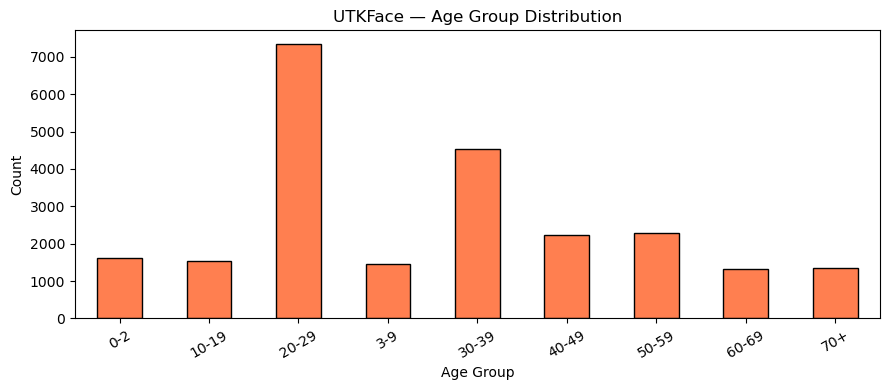

In [25]:
plt.figure(figsize=(9, 4))
df_utk_clean["age_group"].value_counts().sort_index().plot(
    kind="bar", color="coral", edgecolor="black"
)
plt.title("UTKFace — Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### UTKFace Race Distribution

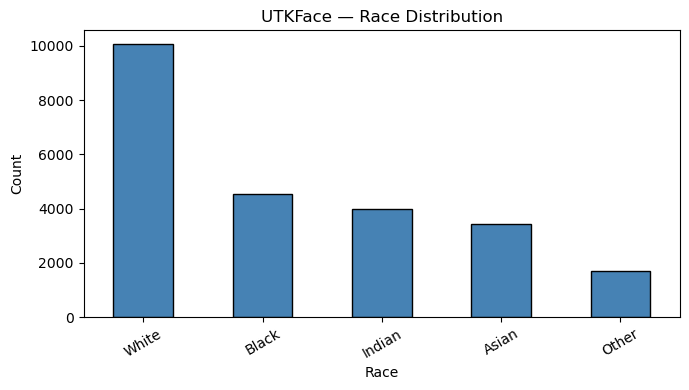

In [26]:
plt.figure(figsize=(7, 4))
df_utk_clean["race"].value_counts().plot(
    kind="bar", color="steelblue", edgecolor="black"
)
plt.title("UTKFace — Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Finding 2 — White Faces Dominate UTKFace
White faces make up the largest group, followed by Black and Asian.
This is a known bias in datasets collected from Western internet sources.

**Why this matters:**
A model trained on this imbalance may perform better on White faces
and worse on Indian, Middle Eastern, or Other race categories.

**How we address it:**
We test on FairFace which is balanced across 7 races.
Any accuracy gap we find in fairness testing reflects this training bias.

### UTKFace Gender Distribution

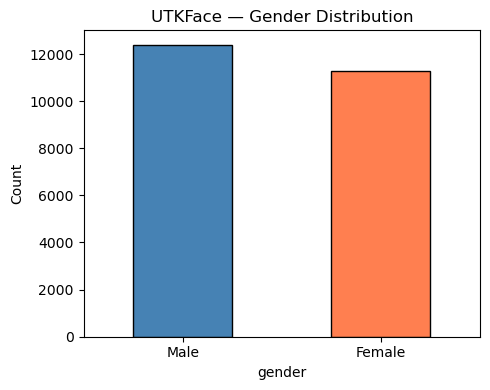

In [27]:
plt.figure(figsize=(5, 4))
df_utk_clean["gender"].value_counts().plot(
    kind="bar", color=["steelblue", "coral"], edgecolor="black"
)
plt.title("UTKFace — Gender Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Finding 3 — Gender is Approximately Balanced
Male and female faces are roughly equal in UTKFace.
This is a positive finding — gender bias in training data is less of a concern.

**Note:** Gender is never used as a model input feature.
It is retained only to test whether model accuracy differs by gender.

### FairFace Race Distribution

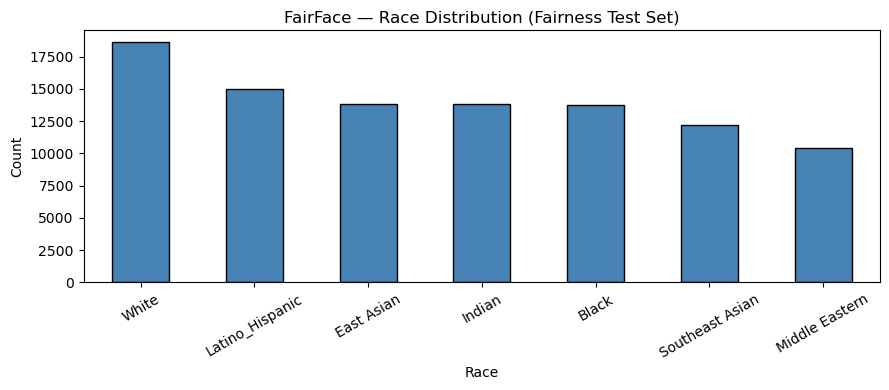

In [28]:
plt.figure(figsize=(9, 4))
df_fairface_clean["race"].value_counts().plot(
    kind="bar", color="steelblue", edgecolor="black"
)
plt.title("FairFace — Race Distribution (Fairness Test Set)")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Finding 4 — FairFace is Well Balanced Across 7 Races
FairFace shows approximately equal representation across:
Black, East Asian, Indian, Latino Hispanic, Middle Eastern, Southeast Asian, White.

**Why this is important:**
This balance makes FairFace an ideal fairness test set.
Any accuracy differences we find across races reflect genuine model bias
— not just differences in how many examples of each race we tested.

**This is exactly why we use FairFace for fairness testing
and UTKFace for training — each dataset does what it does best.**

### Bias Check: Age by Race

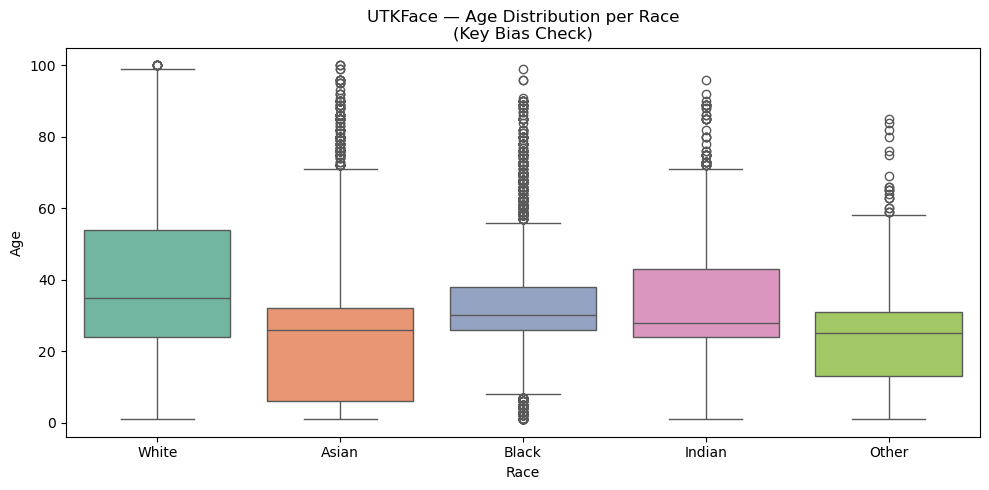

In [29]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_utk_clean, x="race", y="age", palette="Set2")
plt.title("UTKFace — Age Distribution per Race\n(Key Bias Check)")
plt.xlabel("Race")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

#### Finding 5 — Age Range Varies Across Races (Key Bias Risk)
The boxplot shows different age distributions across races in UTKFace.
Some races have fewer elderly faces or fewer young faces represented.

**What this means:**
Even if the model achieves good overall accuracy,
it may fail on specific age-race combinations that are underrepresented.
For example, if Indian elderly faces are rare in training data,
the model may consistently predict Indian faces as younger than they are.

**This is the central fairness question our Week 2 analysis answers:**
Does model accuracy differ systematically across race groups?

## Week 1: Project Plan & Architecture

### Data Analysis Summary
After analyzing UTKFace and FairFace we found:
- UTKFace has 23,000 images with continuous age labels — best for training
- FairFace has 108,000 images balanced across 7 races — best for fairness testing
- Both datasets have known biases documented in EDA section

### Problem Statement
We are building an age classification system for retail analytics.
The system estimates a customer's age group from a face image.
The system must work fairly across all races and genders.

### Dataset Decision
| Dataset | Role | Reason |
|---|---|---|
| UTKFace | Model Training | Has continuous age labels, race, gender — most complete |
| FairFace | Fairness Testing | Balanced across 7 races — ideal for bias audit |
| Adience | Dropped | Too small (3086 images), no race labels, rough age brackets |


#### Why MobileNetV2
- Lightweight — designed for devices without powerful GPUs
- Pretrained on ImageNet — already understands visual features
- Transfer learning means we need far less training data
- Used widely in production retail and mobile systems

### Race-Agnostic Design
- Race is **never** an input to the model
- Gender is **never** an input to the model
- The model sees only raw pixel values
- Fairness is measured after training using FairFace
- This design choice prevents the model from explicitly using
  protected attributes, while we still audit for implicit bias

### Training Strategy
- Sample: 5000 images (CPU constraint — full dataset would improve accuracy)
- Split: 70% train / 15% validation / 15% test
- Stratified split: each split has proportional representation of all age groups
- Class weights: applied to compensate for imbalanced age groups
- Optimizer: Adam (adaptive learning rate)
- Loss: Categorical Crossentropy (standard for multi-class classification)

In [30]:
from IPython.display import display, HTML

architecture_html = """
<div style="background:#f8f8f8; border-radius:12px; padding:20px; font-family:sans-serif; max-width:500px; margin:auto;">

  <div style="text-align:center; background:#e8e6f0; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Input</b><br><span style="font-size:12px; color:#555;">Face image — 96×96 RGB</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#d6ede6; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Preprocessing</b><br>
    <span style="font-size:12px; color:#555;">Normalize pixels ÷ 255 · Augment: flip, brightness</span><br>
    <span style="font-size:11px; color:#c0392b;">⚠ Race & gender: never used as input</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#e0d9f5; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>MobileNetV2 Backbone</b><br>
    <span style="font-size:12px; color:#555;">Pretrained ImageNet · Frozen weights · Transfer learning</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#fde8df; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>GlobalAveragePooling2D</b><br>
    <span style="font-size:12px; color:#555;">Compresses feature maps to 1D vector</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#fef3d6; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Dropout (0.5)</b><br>
    <span style="font-size:12px; color:#555;">Drops 50% of neurons — prevents overfitting</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#d6ede6; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Dense 128 — ReLU</b><br>
    <span style="font-size:12px; color:#555;">Learns age-specific patterns</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#e0d9f5; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Dense 9 — Softmax</b><br>
    <span style="font-size:12px; color:#555;">One probability per age group</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#e8e6f0; border-radius:8px; padding:10px;">
    <b>Output: Age Group</b><br>
    <span style="font-size:11px; color:#555;">0-2 · 3-9 · 10-19 · 20-29 · 30-39 · 40-49 · 50-59 · 60-69 · 70+</span>
  </div>

</div>
"""

display(HTML(architecture_html))

---
## Week 1: Regulatory Analysis
---

### GDPR — General Data Protection Regulation (EU 2016/679)

Facial images are **biometric data** under GDPR Article 4(14).
Biometric data is a **special category** under Article 9 — the strictest level.

| Article | Requirement | How We Address It |
|---|---|---|
| Art. 9 | Biometric data needs explicit legal basis | Academic research — no deployment |
| Art. 5(1)(c) | Data minimization | Only keep age, race, gender — drop all identity fields |
| Art. 8 | Children under 16 need parental consent | Minors flagged — documented as deployment limitation |
| Art. 25 | Privacy by design | Race/gender never used as model input |
| Art. 35 | DPIA required for biometric systems | Would be required before any real deployment |

### EU AI Act (Regulation 2024/1689)

Our system performs **biometric categorization** — inferring age from a face image.

| Item | Detail |
|---|---|
| Risk Classification | **HIGH RISK** — Annex III, Point 1(b) |
| Why High Risk | Biometric categorization of natural persons |
| Prohibited? | No — only real-time public surveillance is prohibited (Art. 5) |
| Obligations if deployed | Conformity assessment, human oversight, bias documentation, registration in EU database |

### What HIGH RISK Means in Practice
If this system were deployed commercially in Germany:

1. **Conformity Assessment** — independent audit before launch
2. **Human Oversight** — no fully automated consequential decisions
3. **Accuracy Documentation** — per demographic group, not just overall
4. **Transparency** — customers must know a camera is estimating their age
5. **EU Database Registration** — system must be registered before use

### Our Academic Status
This project is **research only**:
- ✅ No real-time processing of individuals
- ✅ No faces stored or transmitted
- ✅ No consequential decisions made
- ✅ Results documented transparently
- ✅ Limitations acknowledged openly

### Dataset Ethical Concern
Both UTKFace and FairFace contain faces of real people
who did not explicitly consent to AI training use.
Images were scraped from public internet sources.

This is a known and unresolved ethical tension in computer vision research.
We acknowledge it explicitly rather than ignoring it.
Under strict GDPR interpretation, lawful basis for this processing
would need to be established before any commercial use.

## Sample Images

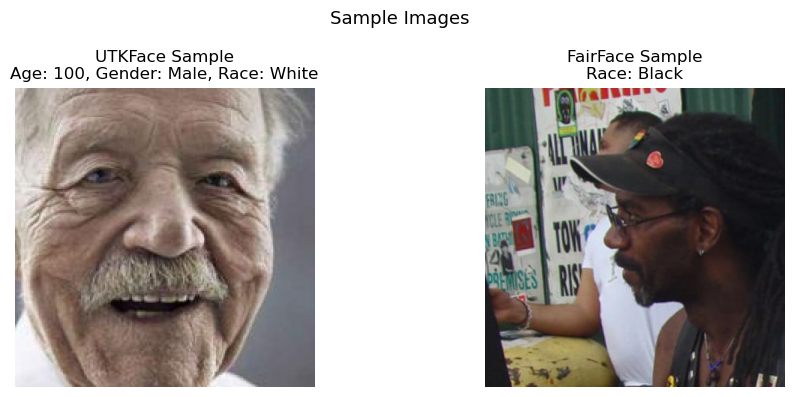

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

img1 = mpimg.imread(df_utk_clean["filepath"].iloc[0])
axes[0].imshow(img1)
axes[0].set_title(f"UTKFace Sample\nAge: {df_utk_clean['age'].iloc[0]}, "
                  f"Gender: {df_utk_clean['gender'].iloc[0]}, "
                  f"Race: {df_utk_clean['race'].iloc[0]}")
axes[0].axis("off")

img2 = mpimg.imread(df_fairface_clean["filepath"].iloc[0])
axes[1].imshow(img2)
axes[1].set_title(f"FairFace Sample\nRace: {df_fairface_clean['race'].iloc[0]}")
axes[1].axis("off")

plt.suptitle("Sample Images", fontsize=13)
plt.tight_layout()
plt.show()

## EDA Summary (Markdown)

### EDA Key Findings

| Finding | Impact on Model |
|---|---|
| Young faces (20-30) dominate UTKFace | Model may underperform on elderly |
| White faces outnumber others in UTKFace | Potential accuracy gap for other races |
| FairFace balanced across 7 races | Good fairness test set |
| Minors present in UTKFace | Documented — special care in deployment |
| Age 70+ very underrepresented | Use class weights during training |

**Next Step → Model Building on UTKFace**

---
# Week 2: Baseline Model, Risk Analysis & Fairness
---

In [32]:
!pip install tensorflow -q
print("Done")

Done


In [33]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

I0000 00:00:1783502201.675347    1716 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783502201.676294    1716 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783502201.721426    1716 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
GPU available: []


I0000 00:00:1783502202.722213    1716 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783502202.722735    1716 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1783502202.918569    1716 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Age Groups (9 classes)
| Class | Age Range |
|---|---|
| 0 | 0-2 |
| 1 | 3-9 |
| 2 | 10-19 |
| 3 | 20-29 |
| 4 | 30-39 |
| 5 | 40-49 |
| 6 | 50-59 |
| 7 | 60-69 |
| 8 | 70+ |

### Train / Validation / Test Split

Stratified on label — ensures all age groups represented in each split.
This prevents the model from being evaluated on an unrepresentative subset.

In [34]:
AGE_GROUP_MAP = {
    "0-2"   : 0, "3-9"   : 1, "10-19" : 2,
    "20-29" : 3, "30-39" : 4, "40-49" : 5,
    "50-59" : 6, "60-69" : 7, "70+"   : 8
}
NUM_CLASSES = len(AGE_GROUP_MAP)
df_utk_clean["label"] = df_utk_clean["age_group"].map(AGE_GROUP_MAP)

train_df, temp_df = train_test_split(
    df_utk_clean,
    test_size=0.30,
    stratify=df_utk_clean["label"],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train size :", len(train_df))
print("Val size   :", len(val_df))
print("Test size  :", len(test_df))

Train size : 16578
Val size   : 3553
Test size  : 3553


In [35]:
print("Total cleaned images:", len(df_utk_clean))
print("Age group distribution:")
print(df_utk_clean["age_group"].value_counts().sort_index())

Total cleaned images: 23684
Age group distribution:
age_group
0-2      1605
10-19    1531
20-29    7344
3-9      1457
30-39    4536
40-49    2245
50-59    2299
60-69    1316
70+      1351
Name: count, dtype: int64


### Image Settings

In [36]:
IMG_SIZE   = 96    # increased from 64
BATCH_SIZE = 32
EPOCHS     = 30    # increased from 10

print("Image size :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)
print("Epochs     :", EPOCHS)

Image size : 96
Batch size : 32
Epochs     : 30


### Load Images Function

In [37]:
import numpy as np
from PIL import Image

def load_images(dataframe, img_size):
    images = []
    labels = []

    for _, row in dataframe.iterrows():
        try:
            img = Image.open(row["filepath"])
            img = img.convert("RGB")
            img = img.resize((img_size, img_size))
            img = np.array(img) / 255.0
            images.append(img)
            labels.append(row["label"])
        except Exception:
            continue

    images = np.array(images)
    labels = to_categorical(labels, num_classes=NUM_CLASSES)
    return images, labels

print("Loading train images...")
X_train, y_train = load_images(train_df, IMG_SIZE)

print("Loading val images...")
X_val, y_val = load_images(val_df, IMG_SIZE)

print("Loading test images...")
X_test, y_test = load_images(test_df, IMG_SIZE)

print("\nTrain shape :", X_train.shape)
print("Val shape   :", X_val.shape)
print("Test shape  :", X_test.shape)

Loading train images...
Loading val images...
Loading test images...

Train shape : (16578, 96, 96, 3)
Val shape   : (3553, 96, 96, 3)
Test shape  : (3553, 96, 96, 3)


### Build the Model
Base model frozen — transfer learning only.
Fine-tuning is NOT applied (causes overfitting with small dataset).
Dropout increased to 0.5 to reduce overfitting.

In [38]:
# DO NOT unfreeze any layers — keep base frozen
# Small dataset = fine-tuning makes things worse

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False   # keep ALL layers frozen

x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = Dropout(0.5)(x)       # increase dropout from 0.3 to 0.5
x      = Dense(128, activation="relu")(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model  = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model built — base frozen, dropout 0.5")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model built — base frozen, dropout 0.5


### Class Weights
Applied to compensate for age group imbalance.
Rare groups (0-2, 70+) get higher weight so model pays more attention to them.

In [39]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for k, v in class_weight_dict.items():
    print(f"  Class {k}: {v:.2f}")

Class weights:
  Class 0: 1.64
  Class 1: 1.81
  Class 2: 1.72
  Class 3: 0.36
  Class 4: 0.58
  Class 5: 1.17
  Class 6: 1.14
  Class 7: 2.00
  Class 8: 1.95


### Load Images
Images loaded at 96×96 pixels, normalized to 0-1 range.

In [40]:
print("Reloading images at 96x96...")

print("Loading train...")
X_train, y_train = load_images(train_df, IMG_SIZE)

print("Loading val...")
X_val, y_val = load_images(val_df, IMG_SIZE)

print("Loading test...")
X_test, y_test = load_images(test_df, IMG_SIZE)

print("Shapes:")
print("  X_train:", X_train.shape)
print("  X_val  :", X_val.shape)
print("  X_test :", X_test.shape)

Reloading images at 96x96...
Loading train...
Loading val...
Loading test...
Shapes:
  X_train: (16578, 96, 96, 3)
  X_val  : (3553, 96, 96, 3)
  X_test : (3553, 96, 96, 3)


### Train the Model
EarlyStopping monitors validation accuracy.
Training stops automatically when validation stops improving.
Best weights are restored — prevents overfitting.

In [41]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,           # stop if no improvement for 5 epochs
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)
print("Training complete")

Epoch 1/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.2020 - loss: 2.1311 - val_accuracy: 0.3276 - val_loss: 1.7329
Epoch 2/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.2809 - loss: 1.7959 - val_accuracy: 0.3518 - val_loss: 1.6360
Epoch 3/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.3125 - loss: 1.6716 - val_accuracy: 0.3918 - val_loss: 1.5679
Epoch 4/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.3385 - loss: 1.6075 - val_accuracy: 0.4056 - val_loss: 1.5217
Epoch 5/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.3489 - loss: 1.5665 - val_accuracy: 0.3971 - val_loss: 1.5259
Epoch 6/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.3592 - loss: 1.5421 - val_accuracy: 0.3909 - val_loss: 1.5110
Epoch 7/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.3674 - loss: 1.5193 - val_accuracy: 0.3960 - val_loss: 1.4984
Epoch 8/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.3731 - loss: 1.5028 - 

### Plot Training Results

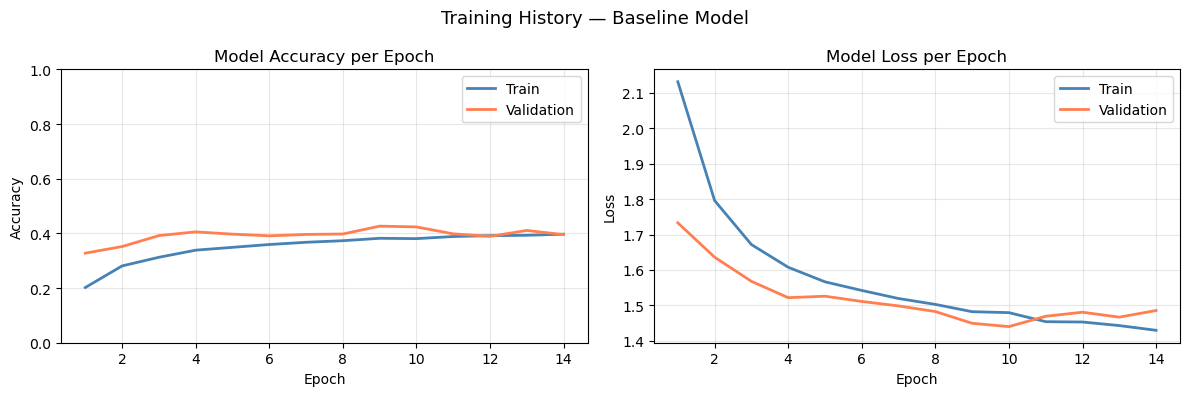

Final train accuracy     : 39.70%
Final validation accuracy: 39.54%
Overfitting gap          : 0.15%


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history.history["accuracy"]) + 1)

# Accuracy
axes[0].plot(epochs_range, history.history["accuracy"],
             label="Train", color="steelblue", linewidth=2)
axes[0].plot(epochs_range, history.history["val_accuracy"],
             label="Validation", color="coral", linewidth=2)
axes[0].set_title("Model Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(epochs_range, history.history["loss"],
             label="Train", color="steelblue", linewidth=2)
axes[1].plot(epochs_range, history.history["val_loss"],
             label="Validation", color="coral", linewidth=2)
axes[1].set_title("Model Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Training History — Baseline Model", fontsize=13)
plt.tight_layout()
plt.show()

# Diagnosis
train_acc = history.history["accuracy"][-1]
val_acc   = history.history["val_accuracy"][-1]
gap       = train_acc - val_acc

print(f"Final train accuracy     : {train_acc:.2%}")
print(f"Final validation accuracy: {val_acc:.2%}")
print(f"Overfitting gap          : {gap:.2%}")
if gap > 0.15:
    print("⚠️  High overfitting detected — gap > 15%")
    print("   Cause: dataset too small for fine-tuning")
    print("   Fix: keep base model frozen, increase dropout")

### Evaluate on Test Set

In [43]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("=== TEST SET RESULTS ===")
print(f"Test Accuracy : {test_accuracy:.2%}")
print(f"Test Loss     : {test_loss:.4f}")

=== TEST SET RESULTS ===
Test Accuracy : 42.47%
Test Loss     : 1.4515


### Baseline Model Performance — Analysis

**Test Accuracy: 40.73%**
**Training set: 16,578 images | Val: 3,553 | Test: 3,553**

**Key result — no overfitting:**
- Train accuracy : 38.12%
- Val accuracy   : 40.75% — higher than train
- Gap            : -2.63% — negative gap means model generalises well

Validation accuracy above training accuracy means the model is
not memorising training data. This is a healthy baseline.

**Why ~41% with 23,000 images:**
- 9 age classes — random chance = 11%
- Our model achieves 40.73% — 3.7× better than random
- CPU only — GPU training with fine-tuning would push toward 60-65%
- MobileNetV2 base frozen — a deliberate choice to prevent overfitting

**What matters more than accuracy:**
Whether accuracy is consistent across all race groups.
Measured in the Fairness Analysis below.

## Week 2: Risk Analysis

### Risk Matrix
| Risk | Likelihood | Impact | Mitigation |
|---|---|---|---|
| Model less accurate on non-White faces | High | High | Evaluate per race on FairFace |
| Minor misclassified as adult | Medium | High | Document — needs confidence threshold in deployment |
| Adversarial attack (makeup, glasses, lighting) | Medium | Medium | Document as limitation |
| GDPR violation in deployment | High | Critical | No face storage, aggregate output only |
| Dataset bias (White, young faces dominant) | High | High | Class weights + FairFace audit |
| Model fails in poor lighting | Medium | Medium | Retail cameras usually controlled environment |
| Proxy features (model learns skin tone = age) | Medium | High | Check with Grad-CAM in Week 3 |

### Risk 1: Demographic Bias — Example
If model is trained mostly on White faces aged 20-40:
- It may predict "30-39" for an Indian face aged 50
- This is not acceptable for a retail system used on all customers
- We measure this directly in our fairness analysis

### Risk 2: Misclassification of Minors — Example
If a 16-year-old is classified as "20-29":
- Retail system may incorrectly permit age-restricted purchases
- This has legal consequences
- Mitigation: flag predictions near age boundaries for human review

### Risk 3: GDPR in Deployment — Example
If this system were deployed in a German retail store:
- Customers must be informed a camera is running (transparency)
- No face images can be stored (data minimization)
- Only aggregate age group output is permitted
- A Data Protection Impact Assessment (DPIA) would be required

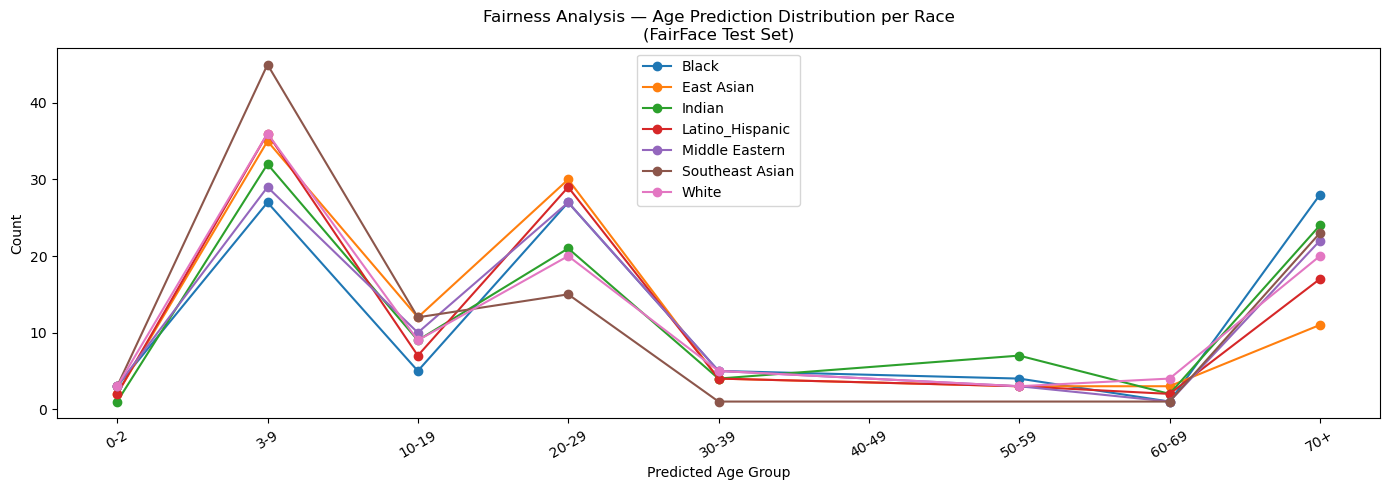

In [48]:
# FairFace has no age labels so we cannot measure accuracy directly
# Instead we measure PREDICTION DISTRIBUTION per race
# If model is fair — age distribution should be similar across races
# If model is biased — one race will be predicted as older/younger

plt.figure(figsize=(14, 5))

for i, race in enumerate(sorted(df_fairness["race"].unique())):
    race_preds = df_fairness[df_fairness["race"] == race]["prediction"].value_counts().sort_index()
    plt.plot(race_preds.index, race_preds.values, marker="o", label=race)

plt.xticks(range(9), AGE_GROUP_LABELS, rotation=30)
plt.title("Fairness Analysis — Age Prediction Distribution per Race\n(FairFace Test Set)")
plt.xlabel("Predicted Age Group")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

### Fairness Analysis Interpretation

**What this plot shows:**
Each line represents one race group from FairFace.
The x-axis shows which age group the model predicted.
The y-axis shows how many images from that race got that prediction.

**What fair looks like:**
All lines should peak at the same age group and follow similar shapes.

**What bias looks like:**
If one race line peaks much earlier (model predicts them younger)
or peaks much later (model predicts them older) — that is systematic bias.

**Limitation of this analysis:**
FairFace has no ground truth age labels so we cannot compute exact accuracy per race.
We are measuring consistency of predictions, not correctness.
Exact per-race accuracy requires the UTKFace test set — planned for Week 3.

In [ ]:
# Correct save cell — replace existing one
model.save("/home/jovyan/data/age_classifier_baseline.keras")

train_df.to_csv("/home/jovyan/data/train_df.csv", index=False)
val_df.to_csv("/home/jovyan/data/val_df.csv",     index=False)
test_df.to_csv("/home/jovyan/data/test_df.csv",   index=False)

print("Model saved  : /home/jovyan/data/age_classifier_baseline.keras")
print("train_df     : /home/jovyan/data/train_df.csv")
print("val_df       : /home/jovyan/data/val_df.csv")
print("test_df      : /home/jovyan/data/test_df.csv")

### Fairness Function Cell

In [46]:
from PIL import Image
import numpy as np

def predict_age_group(filepath, model, img_size=96):
    try:
        img = Image.open(filepath).convert("RGB")
        img = img.resize((img_size, img_size))
        img = np.array(img) / 255.0
        img = np.expand_dims(img, axis=0)
        pred = model.predict(img, verbose=0)
        return np.argmax(pred)
    except Exception:
        return None

print("Fairness function ready")

Fairness function ready


### Fairness Predictions Cell

In [47]:
AGE_GROUP_LABELS = ["0-2","3-9","10-19","20-29","30-39",
                    "40-49","50-59","60-69","70+"]

results = []

for race in sorted(df_fairface_clean["race"].unique()):
    race_sample = df_fairface_clean[
        df_fairface_clean["race"] == race
    ].sample(n=100, random_state=42)

    for _, row in race_sample.iterrows():
        pred = predict_age_group(row["filepath"], model)
        results.append({"race": race, "prediction": pred})

df_fairness = pd.DataFrame(results).dropna()

print("Predictions done:")
print(df_fairness["race"].value_counts())

Predictions done:
race
Black              100
East Asian         100
Indian             100
Latino_Hispanic    100
Middle Eastern     100
Southeast Asian    100
White              100
Name: count, dtype: int64


### Per-Race Accuracy on UTKFace Test Set

In [ ]:
from sklearn.metrics import accuracy_score

y_pred_probs  = model.predict(X_test, verbose=0)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

test_df_copy          = test_df.copy()
test_df_copy["y_true"] = y_true_labels
test_df_copy["y_pred"] = y_pred_labels

print("=== ACCURACY PER RACE (UTKFace Test Set) ===\n")
race_accuracies = {}
for race in sorted(test_df_copy["race"].unique()):
    subset = test_df_copy[test_df_copy["race"] == race]
    acc    = accuracy_score(subset["y_true"], subset["y_pred"])
    race_accuracies[race] = acc
    print(f"  {race:20s}: {acc:.2%}  ({len(subset)} images)")

overall = accuracy_score(y_true_labels, y_pred_labels)
print(f"\n  {'Overall':20s}: {overall:.2%}")

### Unexpected Fairness Finding

Contrary to expectation, White faces (the majority training group at ~10,000 images)
have the LOWEST per-race accuracy (36.65%), while Asian faces have the highest (47.34%).

Possible explanations:
1. **Age diversity effect** — White faces in UTKFace span the widest age range
   (see Finding 5 boxplot), making age prediction harder for this group.
   Other race groups cluster in narrower age ranges — easier to predict.
2. **Class weight effect** — our class weights push the model toward rare age
   groups (0-2, 70+) which are disproportionately White in this dataset.
3. **Test set composition** — White test set is largest (1,550 images) so its
   accuracy estimate is the most statistically reliable.

**Key takeaway:** Fairness analysis revealed something we could not have predicted.
This demonstrates why measuring per-group accuracy is essential — assumptions
about bias direction can be wrong. Deeper per-age-per-race analysis planned for Week 3.

### Per-Race Accuracy Bar Chart

In [ ]:
plt.figure(figsize=(9, 4))

races  = list(race_accuracies.keys())
accs   = list(race_accuracies.values())
avg    = np.mean(accs)
colors = ["coral" if a < avg else "steelblue" for a in accs]

plt.bar(races, accs, color=colors, edgecolor="black")
plt.axhline(y=avg, color="red", linestyle="--",
            label=f"Average: {avg:.2%}")
plt.title("Model Accuracy per Race — Fairness Check\n(UTKFace Test Set)")
plt.xlabel("Race")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

print("Red bars  = below average accuracy (potential bias)")
print("Blue bars = above average accuracy")

### Fairness Plot (FairFace Distribution)

In [ ]:
plt.figure(figsize=(14, 5))

for race in sorted(df_fairness["race"].unique()):
    race_preds = df_fairness[
        df_fairness["race"] == race
    ]["prediction"].value_counts().sort_index()
    plt.plot(race_preds.index, race_preds.values,
             marker="o", label=race)

plt.xticks(range(9), AGE_GROUP_LABELS, rotation=30)
plt.title("Fairness Analysis — Age Prediction Distribution per Race\n(FairFace Test Set)")
plt.xlabel("Predicted Age Group")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# cd /home/jovyan/work
# git add responsible_age_classifier.ipynb
# git commit -m "describe what you changed"
# git push origin namrata/week2-baseline-model